# Download Sept-Nov 2025 Harbin Sentinel-2 scenes (Colab)

Runs `download-haerbing-sepnov-sentinel2-data.py` from Colab instead of your local machine. The script itself lives in the repo and is unchanged -- this notebook just handles two things Colab needs that your local `venv` run didn't:

1. **Credentials**: `.env.cdse` is deliberately gitignored (a CDSE username/password should never be pushed to a public repo -- see the file's own setup comment), so it isn't in the cloned repo on Colab. Fix: upload your local `.env.cdse` to Google Drive once, next to your dataset tars, and this notebook loads it from there into the session's environment variables -- it is never written to the Colab VM's disk or printed anywhere in this notebook's output.
2. **Output location**: the script downloads scenes to `Haerbing_Dataset_sepnov/` on local disk. Colab's disk is wiped when the runtime disconnects, so this notebook copies the finished result to Drive at the end -- do this in the *same* runtime as the download (not a fresh session later).

**One-time setup before running this notebook**: in Google Drive, go to the same `COMP0173/` folder you uploaded the ground-truth tars to, and upload your local `.env.cdse` file there (Drive web UI: drag and drop, or right-click > File upload). It's a two-line text file, no need to tar it.

In [1]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_DIR = "/content/COMP0173_poster_pre"
    if not os.path.exists(REPO_DIR):
        !git clone -q https://github.com/jy-gfm/COMP0173_poster_pre.git {REPO_DIR}
    os.chdir(REPO_DIR)

    DRIVE_DIR = "/content/drive/MyDrive/COMP0173/"
else:
    DRIVE_DIR = "./"


Mounted at /content/drive


## Load credentials from Drive (not from the repo -- `.env.cdse` is gitignored on purpose)

In [2]:
def load_env_file(path):
    if not os.path.exists(path):
        raise RuntimeError(
            f"{path} not found. Upload your local .env.cdse to the COMP0173/ "
            "folder in Google Drive first (see this notebook's opening cell)."
        )
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            os.environ[key.strip()] = value.strip()

load_env_file(os.path.join(DRIVE_DIR, ".env.cdse"))
assert os.environ.get("CDSE_USERNAME") and os.environ.get("CDSE_PASSWORD"), "credentials didn\'t load"
print("Credentials loaded into this session only -- not written to disk, not printed.")


Credentials loaded into this session only -- not written to disk, not printed.


## Run the download script

Same script as the local `venv` version -- `download-haerbing-sepnov-sentinel2-data.py` already reads `CDSE_USERNAME`/`CDSE_PASSWORD` from the environment, which the cell above just populated. This can take a while (14+ scenes, ~1GB each) -- if the runtime disconnects partway through, just re-run this cell: the script skips any `.SAFE` folder it already downloaded.

In [3]:
!git -C /content/COMP0173_poster_pre pull

Already up to date.


In [ ]:
!python download-haerbing-sepnov-sentinel2-data.py


In [ ]:
#Manually check the download scencs

72 downloaded scenes to preview


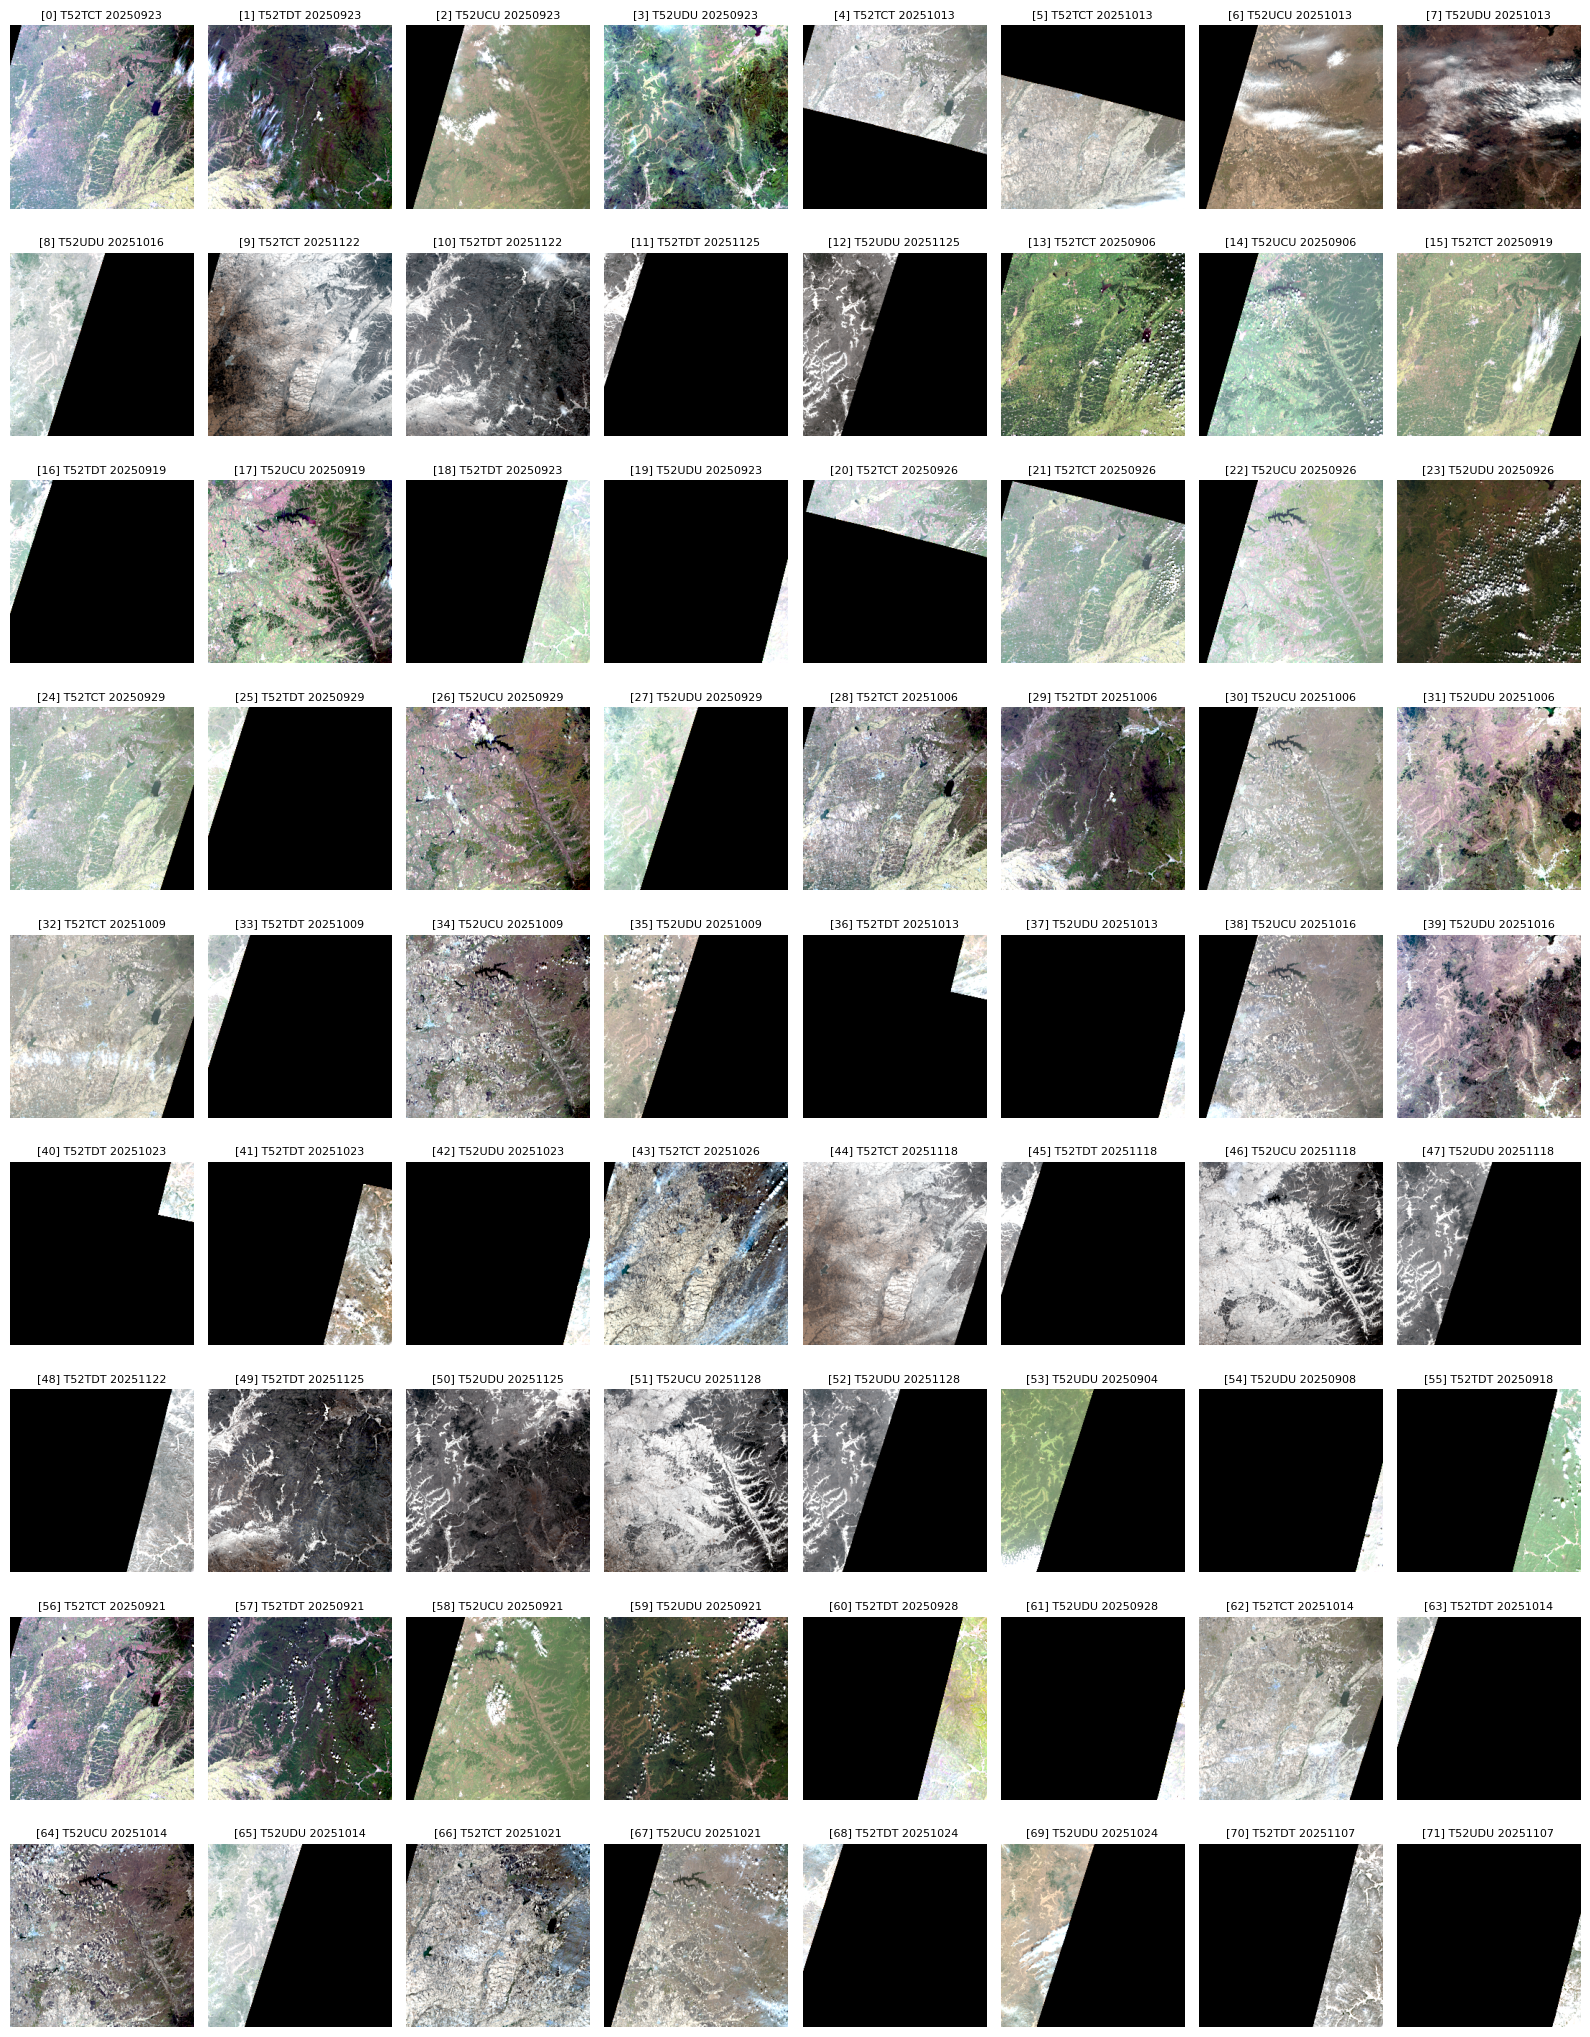

In [7]:
import os
import glob
import re
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

OUTPUT_DIR = "Haerbing_Dataset_sepnov"
SAFE_NAME_RE = re.compile(
    r"^(?P<sensor>S2[ABC])_MSIL2A_(?P<date>\d{8})T\d{6}_N\d{4}_R\d{3}_"
    r"(?P<tile>T\d{2}[A-Z]{3})_\d{8}T\d{6}\.SAFE$"
)
BOA_ADD_OFFSET = -1000
REFLECTANCE_SCALE = 10000

def find_granule_dir(safe_path):
    granule_root = f"{safe_path}/GRANULE"
    subdirs = [d for d in os.listdir(granule_root) if not d.startswith('.')]
    return f"{granule_root}/{subdirs[0]}"

def band_path(granule_dir, band):
    matches = glob.glob(f"{granule_dir}/IMG_DATA/R10m/*_{band}_10m.jp2")
    return matches[0]

def quicklook_rgb(safe_path, size=256):
    granule_dir = find_granule_dir(safe_path)
    def read_small(band):
        with rasterio.open(band_path(granule_dir, band)) as src:
            arr = src.read(1, out_shape=(size, size), resampling=Resampling.average).astype(np.float32)
        return np.clip((arr + BOA_ADD_OFFSET) / REFLECTANCE_SCALE, 0.0, 1.0)
    rgb = np.stack([read_small(b) for b in ("B04", "B03", "B02")], axis=-1)
    stretched = np.zeros_like(rgb)
    for c in range(3):
        lo, hi = np.percentile(rgb[:, :, c], [2, 98])
        stretched[:, :, c] = np.clip((rgb[:, :, c] - lo) / max(hi - lo, 1e-6), 0, 1)
    return np.clip(stretched, 0, 1) ** 0.6

safe_dirs = sorted(glob.glob(f"{OUTPUT_DIR}/*.SAFE"))
print(f"{len(safe_dirs)} downloaded scenes to preview")

cols = 8
rows = (len(safe_dirs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.3))
axes = axes.flatten()
for i, safe_path in enumerate(safe_dirs):
    m = SAFE_NAME_RE.match(os.path.basename(safe_path))
    try:
        axes[i].imshow(quicklook_rgb(safe_path))
    except Exception as e:
        axes[i].text(0.5, 0.5, f"error:\n{e}", ha="center", va="center", fontsize=6, wrap=True)
    axes[i].set_title(f"[{i}] {m.group('tile')} {m.group('date')}", fontsize=8)
    axes[i].axis("off")
for j in range(len(safe_dirs), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
#KEEP any good scences i checked

In [ ]:
import shutil

KEEP_INDICES = [0, 1, 3, 13, 17, 23, 26, 28, 29, 31, 34, 39, 43, 56, 57, 59, 64, 66]  # e.g. [0, 1, 2, 8, 9] -- fill in with the indices worth keeping, from the grid above

assert KEEP_INDICES, "KEEP_INDICES is empty -- list the indices you want to keep, or this would exclude everything"

EXCLUDED_DIR = f"{OUTPUT_DIR}_excluded"
os.makedirs(EXCLUDED_DIR, exist_ok=True)

exclude_indices = [i for i in range(len(safe_dirs)) if i not in KEEP_INDICES]
for i in exclude_indices:
    safe_path = safe_dirs[i]
    dest = os.path.join(EXCLUDED_DIR, os.path.basename(safe_path))
    shutil.move(safe_path, dest)
    print(f"excluded [{i}]: {os.path.basename(safe_path)}")

print(f"\n{len(exclude_indices)} scene(s) moved to {EXCLUDED_DIR}, "
      f"{len(KEEP_INDICES)} remain in {OUTPUT_DIR}")


## Copy the result to Drive

Do this before the runtime disconnects -- `Haerbing_Dataset_sepnov/` on Colab's local disk does not survive a disconnect. A single tar archive is more reliable to upload/download than thousands of individual files (same reasoning as every other dataset in this project).

In [9]:
if IN_COLAB:
    TAR_NAME = "Haerbing_Dataset_sepnov"
    !tar -cf {TAR_NAME}.tar {TAR_NAME}
    import shutil
    shutil.copy(f"{TAR_NAME}.tar", DRIVE_DIR)
    print(f"Saved {TAR_NAME}.tar to {DRIVE_DIR}")


Saved Haerbing_Dataset_sepnov.tar to /content/drive/MyDrive/COMP0173/


In [11]:
!pip install -q rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.4 MB/s eta 0:00:00


In [61]:
!nohup python -u preprocess-haerbing-sepnov-sentinel2-data.py > preprocess.log 2>&1 &
print("started in background (unbuffered), poll preprocess.log in the next cell")


started in background (unbuffered), poll preprocess.log in the next cell


In [81]:
!tail -30 preprocess.log

[8/18] T52TCT 20251006 ...
    kept 435 tiles, discarded 6 (cloud/nodata > 10%)
[9/18] T52TDT 20251006 ...
    kept 441 tiles, discarded 0 (cloud/nodata > 10%)
[10/18] T52UDU 20251006 ...
    kept 441 tiles, discarded 0 (cloud/nodata > 10%)
[11/18] T52UCU 20251009 ...
    kept 435 tiles, discarded 6 (cloud/nodata > 10%)
[12/18] T52UDU 20251016 ...
    kept 441 tiles, discarded 0 (cloud/nodata > 10%)
[13/18] T52TCT 20251026 ...
    kept 396 tiles, discarded 45 (cloud/nodata > 10%)
[14/18] T52TCT 20250921 ...
    kept 435 tiles, discarded 6 (cloud/nodata > 10%)
[15/18] T52TDT 20250921 ...
    kept 411 tiles, discarded 30 (cloud/nodata > 10%)
[16/18] T52UDU 20250921 ...
    kept 371 tiles, discarded 70 (cloud/nodata > 10%)
[17/18] T52UCU 20251014 ...
    kept 421 tiles, discarded 20 (cloud/nodata > 10%)
[18/18] T52TCT 20251021 ...
    kept 431 tiles, discarded 10 (cloud/nodata > 10%)

Done. Manifest written to Haerbing_processed_sepnov/manifest.json

Distinct kept dates per tile (check be

In [82]:
!python generate-haerbing-sepnov-ground-truth.py

1759 distinct tile positions with at least one clear-sky date

Split counts: {'training': 1232, 'validation': 273, 'test': 254}
Mean forest fraction across positions: 0.089
Positions with >=2 dates (persistence check meaningful): 1756/1759

Done. Manifest written to Haerbing_ground_truth_sepnov/manifest.json
